# Using `grapes.utils` interpolation helpers on bundled data tables

This notebook demonstrates the functions in `grapes/utils.py` on the `.txt` simulation tables in `grapes/data/`:

- `create_A23_interpolators` for Ayromlou+2023 tables
- `create_crocodile_interpolators` for CROCODILE tables

In [1]:
from pathlib import Path
import glob

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from importlib_resources import files

from grapes.defs import cosmo
from grapes.utils import create_A23_interpolators, create_crocodile_interpolators

plt.rcParams.update({'font.size': 12})

In [2]:
# Locate bundled data files
data_dir = Path(files('grapes')) / 'data'
txt_files = sorted(data_dir.glob('*.txt'))
print(f'Data directory: {data_dir}')
print('Available .txt tables:')
for path in txt_files:
    print(' -', path.name)

Data directory: /home/sunil/Python/grapes/grapes/data
Available .txt tables:
 - Ayromlou2023a_Fig2_SIMBA.txt
 - Ayromlou2023a_Fig2_TNG.txt
 - Ayromlou2023b_Fig2_EAGLE.txt
 - Zhao_Zhang_CROCODILE.txt
 - Zhao_Zhang_CROCODILE_gas_only.txt


## 1) Ayromlou+2023 tables with `create_A23_interpolators`

Found 3 Ayromlou files


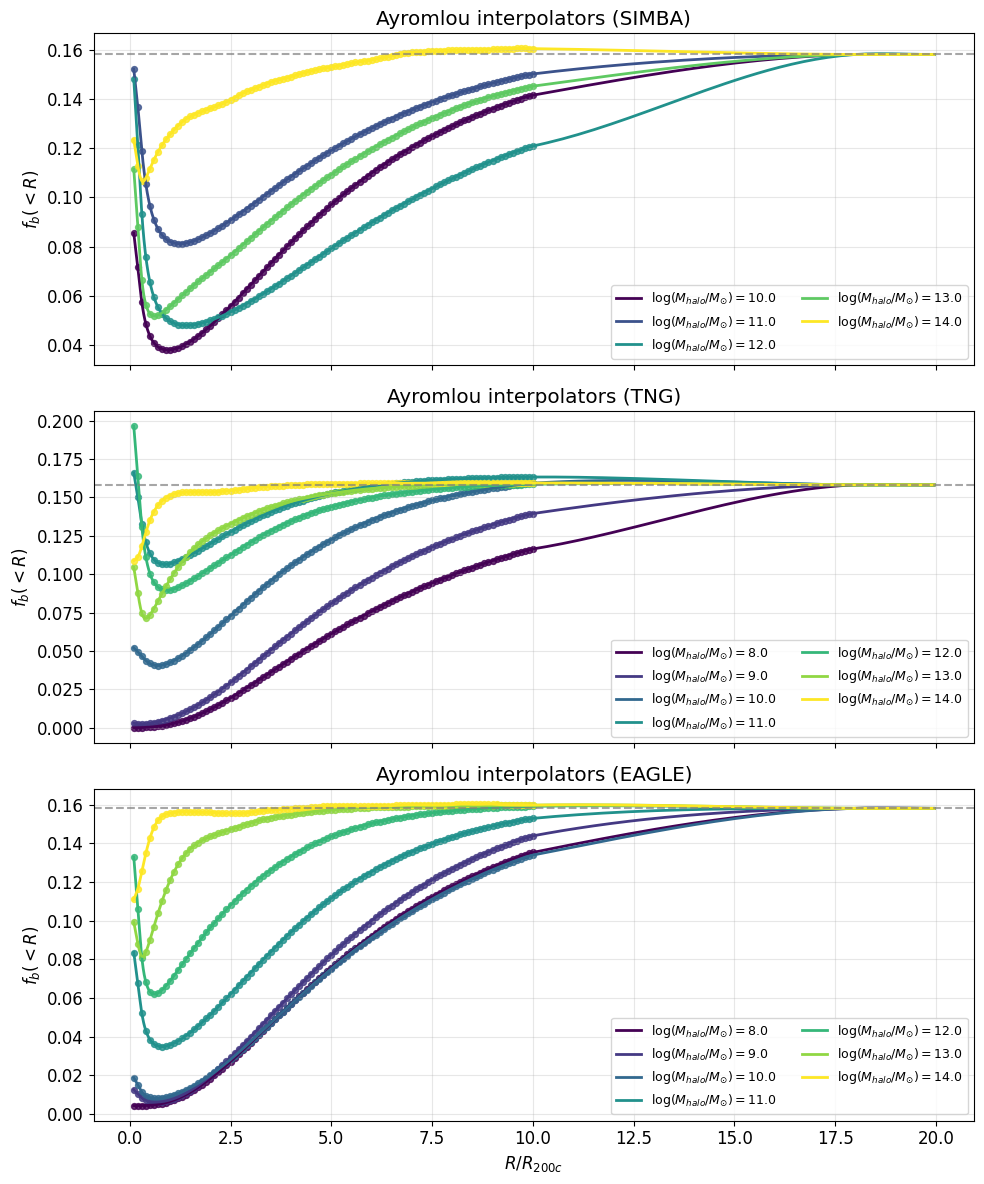

In [3]:
a23_files = sorted(glob.glob(str(data_dir / 'Ayromlou2023*_Fig2_*.txt')))
print(f'Found {len(a23_files)} Ayromlou files')

fig, axes = plt.subplots(len(a23_files), 1, figsize=(10, 4 * max(1, len(a23_files))), sharex=True, tight_layout=True)
if len(a23_files) == 1:
    axes = [axes]

for ax, file_path in zip(axes, a23_files):
    sim = Path(file_path).stem.split('_')[-1]

    tab = Table.read(
        file_path,
        format='ascii',
        names=['model_index', 'halo_mass_index', 'halo_mass_bin_value', 'x=R/R200c', 'y=f_b(<R)/f_b,cosmic']
    )

    mask = np.isfinite(tab['x=R/R200c']) & np.isfinite(tab['y=f_b(<R)/f_b,cosmic'])
    tab = tab[mask]

    interpolators = create_A23_interpolators(tab)
    x_plot = np.logspace(-1, 1.3, 300)

    colors = plt.cm.viridis(np.linspace(0, 1, max(1, len(interpolators))))
    for color, idx in zip(colors, sorted(interpolators.keys())):
        f_interp = interpolators[idx]
        sub = tab[tab['halo_mass_index'] == idx]

        x_data = np.array(sub['x=R/R200c'])
        f_data = np.array(sub['y=f_b(<R)/f_b,cosmic']) * cosmo.Ob0 / cosmo.Om0
        halo_mass = float(sub['halo_mass_bin_value'][0])

        ax.scatter(x_data, f_data, s=18, color=color, alpha=0.8)
        ax.plot(x_plot, f_interp(x_plot), color=color, lw=2,
                label=rf'$\log(M_{{halo}}/M_{{\odot}})={halo_mass:.1f}$')

    ax.axhline(cosmo.Ob0 / cosmo.Om0, color='gray', ls='--', lw=1.5, alpha=0.7)
    #ax.set_xscale('log')
    ax.set_ylabel(r'$f_b(<R)$')
    ax.set_title(f'Ayromlou interpolators ({sim})')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=9, ncol=2)

axes[-1].set_xlabel(r'$R/R_{200c}$')
plt.show()

## 2) CROCODILE tables with `create_crocodile_interpolators`

AGN label = f: 6 interpolators


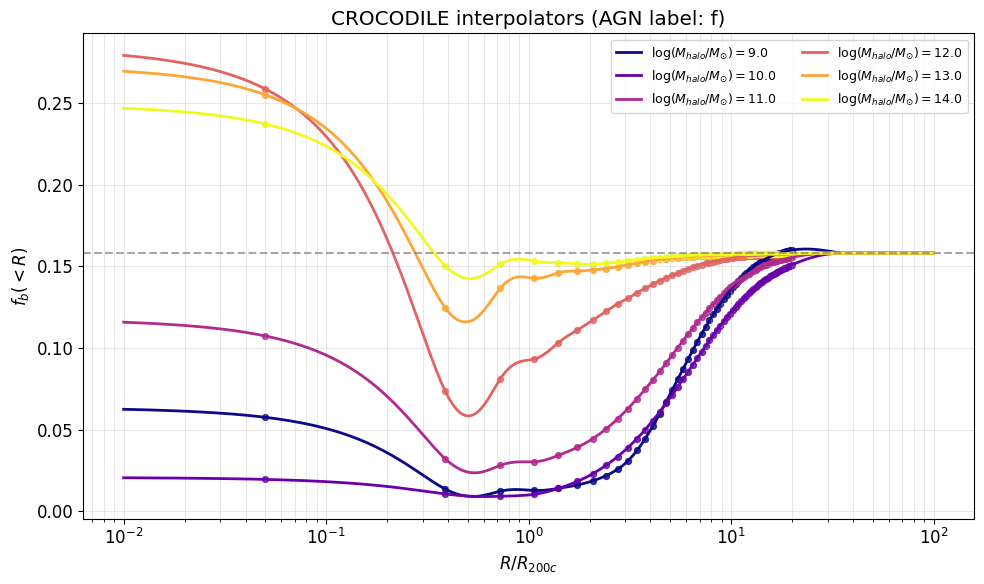

AGN label = n: 6 interpolators


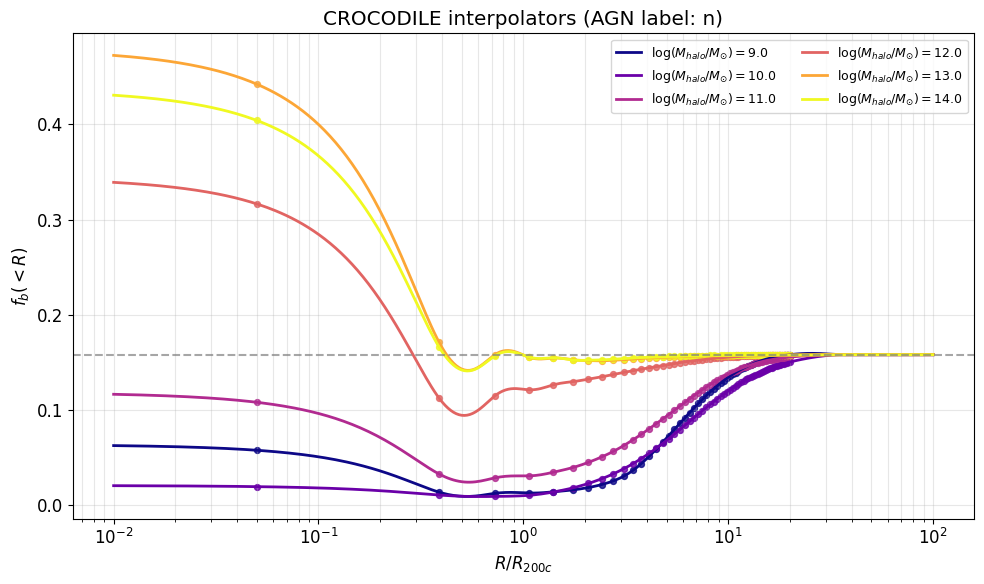

In [4]:
croc_file = data_dir / 'Zhao_Zhang_CROCODILE.txt'
croc_tab = Table.read(
    str(croc_file),
    format='ascii',
    names=['logM_lo', 'logM_up', 'label_AGN', 'R_over_R200', 'fb_med_norm', 'fb_p16_norm', 'fb_p84_norm']
)

mask = np.isfinite(croc_tab['R_over_R200']) & np.isfinite(croc_tab['fb_med_norm'])
croc_tab = croc_tab[mask]

for agn_label in ['f', 'n']:
    interpolators = create_crocodile_interpolators(croc_tab, AGN_label=agn_label)
    print(f'AGN label = {agn_label}: {len(interpolators)} interpolators')

    x_plot = np.logspace(-2, 2, 300)
    fig, ax = plt.subplots(figsize=(10, 6), tight_layout=True)
    colors = plt.cm.plasma(np.linspace(0, 1, max(1, len(interpolators))))

    for color, logm in zip(colors, sorted(interpolators.keys())):
        f_interp = interpolators[logm]
        sub = croc_tab[(croc_tab['logM_lo'] == logm) & (croc_tab['label_AGN'] == agn_label)]

        x_data = np.array(sub['R_over_R200'])
        f_data = np.array(sub['fb_med_norm']) * cosmo.Ob0 / cosmo.Om0

        ax.scatter(x_data, f_data, s=18, color=color, alpha=0.8)
        ax.plot(x_plot, f_interp(x_plot), color=color, lw=2,
                label=rf'$\log(M_{{halo}}/M_{{\odot}})={logm:.1f}$')

    ax.axhline(cosmo.Ob0 / cosmo.Om0, color='gray', ls='--', lw=1.5, alpha=0.7)
    ax.set_xscale('log')
    ax.set_xlabel(r'$R/R_{200c}$')
    ax.set_ylabel(r'$f_b(<R)$')
    ax.set_title(f'CROCODILE interpolators (AGN label: {agn_label})')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=9, ncol=2)
    plt.show()